# Dividend Omission Effects


1. uses **known discrete cash dividends** only when the ex-dividend date falls after the snapshot and before the September 19, 2025 option expiration;
2. applies both the **upper and lower call quote-consistency bounds** in a ticker-neutral filtering pipeline;
3. documents the NVIDIA June 2024 ten-for-one split and stale-record issue without manual ticker-specific rescaling;
4. shows why retaining stale pre-split-scale records would distort normalized moneyness and model-error summaries;
5. scales the mechanical dividend-omission effect by the **bid–ask half-spread**;
6. keeps independently estimated pre-sample historical volatility as the primary volatility input;
7. documents the September 5, 2025 acquisition gap and does **not** reconstruct a historical Yahoo option chain ex post;
8. stratifies pricing errors by **moneyness**;
9. reports numerical robustness checks for volatility windows, activity thresholds, spread caps, and the former continuous-yield specification;
10. includes auxiliary **intrinsic-value** and **escrowed-dividend CRR** diagnostics for the American-style nature of the observed contracts;
11. includes hard numerical checks against the values reported in the final manuscript.

The notebook is self-contained when run from a repository/project root containing `data/`. In Google Colab it first checks the GitHub repository and, if the required synchronized data are not present, prompts for a ZIP containing the final project data.


In [1]:
# Colab/local setup — run this cell first
from pathlib import Path
import os, sys, subprocess, platform, zipfile, shutil, importlib.util

IN_COLAB = 'google.colab' in sys.modules
REPO_URL = 'https://github.com/abdallahmaiga10/BSM-option-pricing.git'
EXPECTED_OPTION_FILES = 13

required = {'numpy':'numpy','pandas':'pandas','scipy':'scipy','statsmodels':'statsmodels','matplotlib':'matplotlib'}
missing = [pkg for mod,pkg in required.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.check_call([sys.executable,'-m','pip','install','-q',*missing])

def data_complete(root: Path) -> bool:
    data = root/'data'
    return (
        data.exists()
        and len(list(data.glob('calls-2025-*.csv'))) == EXPECTED_OPTION_FILES
        and (data/'historical_closes_presample.csv').exists()
        and (data/'discrete_dividends.csv').exists()
    )

if IN_COLAB:
    ROOT = Path('/content/BSM-option-pricing')
    if not data_complete(ROOT):
        if ROOT.exists():
            shutil.rmtree(ROOT)
        try:
            subprocess.run(['git','clone','--depth','1',REPO_URL,str(ROOT)],check=True)
        except Exception:
            pass

    if not data_complete(ROOT):
        from google.colab import files
        print('The GitHub copy is missing the synchronized final data.')
        print('Please upload ZIP file containing the data directly.')
        uploaded = files.upload()
        if not uploaded:
            raise RuntimeError('No data archive uploaded.')
        name = next(iter(uploaded))
        up = Path('/content')/name
        if up.suffix.lower() != '.zip':
            raise ValueError('Please upload a ZIP file.')
        extract_root = Path('/content/uploaded_final_project')
        if extract_root.exists():
            shutil.rmtree(extract_root)
        with zipfile.ZipFile(up) as z:
            z.extractall(extract_root)
        candidates = [p.parent.parent for p in extract_root.rglob('historical_closes_presample.csv')]
        candidates = [p for p in candidates if data_complete(p)]
        if not candidates:
            raise FileNotFoundError('Could not locate a complete final data/ folder in the uploaded ZIP.')
        ROOT = candidates[0]
    os.chdir(ROOT)
else:
    ROOT = Path.cwd()
    if not data_complete(ROOT):
        candidates=[]
        if Path('/mnt/data').exists():
            for p in Path('/mnt/data').rglob('historical_closes_presample.csv'):
                candidate=p.parent.parent
                if data_complete(candidate):
                    candidates.append(candidate)
        if not candidates:
            raise FileNotFoundError('Run the notebook from a project root containing the synchronized final data/ folder.')
        ROOT = candidates[0]
        os.chdir(ROOT)

print('Project root:', ROOT)
print('Option snapshot files:', len(list((ROOT/'data').glob('calls-2025-*.csv'))))


The GitHub copy is missing the synchronized final data.
Please upload ZIP file containing the data directly.


Saving data.zip to data (1).zip
Project root: /content/uploaded_final_project
Option snapshot files: 13


In [2]:
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import norm, ttest_rel, wilcoxon
from statsmodels.stats.multitest import multipletests
from IPython.display import display

FIG = ROOT / 'revised_outputs_final_draft' / 'figures'
TAB = ROOT / 'revised_outputs_final_draft' / 'tables'
FIG.mkdir(parents=True, exist_ok=True)
TAB.mkdir(parents=True, exist_ok=True)

RISK_FREE = 0.0441
EXPIRY = pd.Timestamp('2025-09-19')
HOLIDAYS = np.array(['2025-09-01'], dtype='datetime64[D]')
TICKERS = ['AAPL','BAC','JPM','MRK','MSFT','NVDA','PFE','UNH','WFC']
EXPECTED_SNAPSHOTS = pd.to_datetime(['2025-08-29','2025-09-02','2025-09-03','2025-09-04','2025-09-08','2025-09-09','2025-09-10','2025-09-11','2025-09-12','2025-09-15','2025-09-16','2025-09-17','2025-09-18'])

print('Python:', platform.python_version())
print('NumPy:', np.__version__)
print('pandas:', pd.__version__)


Python: 3.13.15
NumPy: 2.1.3
pandas: 2.2.3


## 1. Declared dividend schedule

For normal U.S. cash dividends after the May 2024 move to T+1 settlement, the ex-dividend date is the record date when the record date is a business day (FINRA Rule 11140). The schedule file stores the issuer-reported record/ex-date and amount used in the paper.

A dividend is included only if `snapshot_date < ex_date < expiration`. Therefore AAPL, JPM, MSFT, PFE, and WFC have no relevant dividend during the option life in this sample.

In [3]:
div_path = ROOT/'data'/'discrete_dividends.csv'
if div_path.exists():
    dividends = pd.read_csv(div_path, parse_dates=['ex_date'])
else:
    dividends = pd.DataFrame([
        ('AAPL','2025-08-11',0.26),('BAC','2025-09-05',0.28),('JPM','2025-10-06',1.50),
        ('MRK','2025-09-15',0.81),('MSFT','2025-08-21',0.83),('NVDA','2025-09-11',0.01),
        ('PFE','2025-07-25',0.43),('UNH','2025-09-15',2.21),('WFC','2025-08-08',0.45)
    ], columns=['symbol','ex_date','amount_usd'])
    dividends['ex_date']=pd.to_datetime(dividends['ex_date'])
    dividends = dividends.rename(columns={'amount_usd':'dividend_amount'})
if 'amount_usd' in dividends.columns:
    dividends = dividends.rename(columns={'amount_usd':'dividend_amount'})
display(dividends[['symbol','ex_date','dividend_amount']])


,symbol,ex_date,dividend_amount
0,AAPL,2025-08-11,0.26
1,BAC,2025-09-05,0.28
2,JPM,2025-10-06,1.50
3,MRK,2025-09-15,0.81
4,MSFT,2025-08-21,0.83
5,NVDA,2025-09-11,0.01
6,PFE,2025-07-25,0.43
7,UNH,2025-09-15,2.21
8,WFC,2025-08-08,0.45


## 2. Load the archived option-chain snapshots and audit timing

The analysis uses the **13 option-chain snapshots successfully archived by the original acquisition workflow**: August 29 and September 2–4, 8–12, and 15–18, 2025. September 1 was Labor Day and the market was closed.

**September 5 was a normal trading day, but the scheduled option-chain acquisition process failed and did not produce a reliable, complete snapshot.** The archived files do not establish the underlying technical cause. Consistent with the final manuscript, the analysis therefore excludes the September 5 output rather than repairing, selectively retaining, or reconstructing the historical Yahoo chain ex post.

For BAC, whose ex-dividend date is September 5, the dividend adjustment consequently applies only to the available pre-ex-date snapshots (August 29 and September 2–4), and to no later observations.


In [4]:
raws=[]
for p in sorted((ROOT/'data').glob('calls-2025-*.csv')):
    d=pd.read_csv(p)
    d['snapshot_date']=pd.Timestamp(re.search(r'(2025-\d{2}-\d{2})',p.name).group(1))
    raws.append(d)
raw=pd.concat(raws,ignore_index=True)

raw['lastTradeDate_parsed']=pd.to_datetime(raw['lastTradeDate'],utc=True,errors='coerce').dt.tz_convert(None)
raw['last_trade_date']=raw['lastTradeDate_parsed'].dt.normalize()
valid=raw['last_trade_date'].notna()
age=np.full(len(raw),np.nan)
age[valid.to_numpy()] = np.busday_count(
    raw.loc[valid,'last_trade_date'].values.astype('datetime64[D]'),
    raw.loc[valid,'snapshot_date'].values.astype('datetime64[D]'), holidays=HOLIDAYS)
raw['trade_age_sessions']=age
raw['trade_age_calendar_days']=(raw.snapshot_date-raw.last_trade_date).dt.days

for c in ['bid','ask','stockPrice','strike','impliedVolatility']:
    raw[c]=pd.to_numeric(raw[c],errors='coerce')
raw['market_mid']=(raw.bid+raw.ask)/2
raw['S']=raw.stockPrice; raw['K']=raw.strike; raw['yahoo_iv']=raw.impliedVolatility
raw['T_years']=(EXPIRY-raw.snapshot_date).dt.days/365.0
raw['K_over_S']=raw.K/raw.S
raw=raw.merge(dividends[['symbol','ex_date','dividend_amount']],on='symbol',how='left')
raw['div_relevant']=(raw.ex_date>raw.snapshot_date)&(raw.ex_date<EXPIRY)
raw['tau_div_days']=(raw.ex_date-raw.snapshot_date).dt.days
raw['tau_div']=np.where(raw.div_relevant,raw.tau_div_days/365.0,np.nan)
raw['PV_div']=np.where(raw.div_relevant,raw.dividend_amount*np.exp(-RISK_FREE*raw.tau_div),0.0)
raw['S_adj']=raw.S-raw.PV_div
raw['lower_bound']=np.maximum(0,raw.S_adj-raw.K*np.exp(-RISK_FREE*raw.T_years))
raw['half_spread']=(raw.ask-raw.bid)/2
raw['relative_spread']=(raw.ask-raw.bid)/raw.market_mid
print('Raw rows:',len(raw))
display(raw.groupby('symbol').size().rename('Raw N').to_frame())


snapshot_dates = pd.DatetimeIndex(sorted(raw['snapshot_date'].unique()))
print('Archived snapshot dates:', [d.strftime('%Y-%m-%d') for d in snapshot_dates])
assert snapshot_dates.equals(pd.DatetimeIndex(EXPECTED_SNAPSHOTS))
assert pd.Timestamp('2025-09-05') not in snapshot_dates
snapshot_calendar = pd.DataFrame({
    'date': pd.to_datetime(['2025-08-29','2025-09-01','2025-09-02','2025-09-03','2025-09-04','2025-09-05','2025-09-08','2025-09-09','2025-09-10','2025-09-11','2025-09-12','2025-09-15','2025-09-16','2025-09-17','2025-09-18']),
    'status': ['archived','market holiday','archived','archived','archived','not archived','archived','archived','archived','archived','archived','archived','archived','archived','archived']
})
snapshot_calendar.to_csv(TAB/'snapshot_calendar.csv',index=False)
display(snapshot_calendar)


Raw rows: 9959


,Raw N
symbol,
AAPL,1061
BAC,708
JPM,839
MRK,620
MSFT,1304
NVDA,3037
PFE,477
UNH,1276
WFC,637


Archived snapshot dates: ['2025-08-29', '2025-09-02', '2025-09-03', '2025-09-04', '2025-09-08', '2025-09-09', '2025-09-10', '2025-09-11', '2025-09-12', '2025-09-15', '2025-09-16', '2025-09-17', '2025-09-18']


,date,status
0,2025-08-29,archived
1,2025-09-01,market holiday
2,2025-09-02,archived
3,2025-09-03,archived
4,2025-09-04,archived
5,2025-09-05,not archived
6,2025-09-08,archived
7,2025-09-09,archived
8,2025-09-10,archived
9,2025-09-11,archived


## 3. Uniform sample filters

Filters are applied in the same order to every ticker:

1. strictly positive, two-sided quotes with `ask >= bid` and valid positive stock/strike prices;
2. call upper bound: \(C^{mkt}\le S\);
3. conservative discrete-dividend lower bound: \(C^{mkt}\ge \max(0,S-PV(D)-Ke^{-rT})\);
4. `lastTradeDate` no more than one U.S. trading session before the snapshot date.

The lower bound is the reviewer-requested no-arbitrage screen adapted to the known discrete dividend. No NVDA-specific deletion or manual split rescaling is used.

In [5]:
stage1=(raw.bid.notna()&raw.ask.notna()&(raw.bid>0)&(raw.ask>0)&(raw.ask>=raw.bid)&
        (raw.S>0)&(raw.K>0)&(raw.market_mid>0)&(raw.T_years>0))
stage2=stage1&(raw.market_mid<=raw.S+1e-12)
stage3=stage2&(raw.market_mid+1e-12>=raw.lower_bound)
stage4=stage3&raw.trade_age_sessions.notna()&(raw.trade_age_sessions>=0)&(raw.trade_age_sessions<=1)

stages=[]
for sym in TICKERS:
    idx=raw.symbol==sym
    stages.append([sym,idx.sum(),(idx&stage1).sum(),(idx&stage2).sum(),(idx&stage3).sum(),(idx&stage4).sum()])
filter_stages=pd.DataFrame(stages,columns=['Ticker','Raw','Valid quotes','Upper bound','Lower bound','Activity'])
display(filter_stages)
print('Overall:', len(raw), stage1.sum(), stage2.sum(), stage3.sum(), stage4.sum())
filter_stages.to_csv(TAB/'filter_stages.csv',index=False)


,Ticker,Raw,Valid quotes,Upper bound,Lower bound,Activity
0,AAPL,1061,865,865,598,482
1,BAC,708,617,617,524,361
2,JPM,839,717,717,522,398
3,MRK,620,368,368,339,262
4,MSFT,1304,1053,1053,825,681
5,NVDA,3037,2660,1885,1424,1002
6,PFE,477,294,294,236,160
7,UNH,1276,831,831,765,662
8,WFC,637,533,533,409,299


Overall: 9959 7938 7163 5642 4307


### NVDA split/stale-record audit

NVIDIA implemented a ten-for-one forward stock split effective June 7, 2024, with split-adjusted trading beginning June 10, 2024. The raw option files contain stale high-strike records whose `lastTradeDate` predates the split-adjusted trading date.

The final manuscript does **not** manually divide strikes or option premiums by ten because the adjustment status of every stale historical contract cannot be reconstructed reliably from the downloaded files. Instead, the same universal filters are applied to every ticker.

Retaining these stale pre-split-scale records would mechanically distort normalized moneyness and contaminate model-error summaries because the strikes and stale transaction information would not represent contemporaneous September 2025 contracts on a comparable economic basis.


In [6]:
nv=raw[raw.symbol=='NVDA']
print('NVDA raw observations:',len(nv))
print('Raw NVDA strikes > $200:',(nv.K>200).sum())
print('...with lastTradeDate before 2024-06-10:',((nv.K>200)&(nv.last_trade_date<pd.Timestamp('2024-06-10'))).sum())
prim_tmp=raw.loc[stage4]
nvf=prim_tmp[prim_tmp.symbol=='NVDA']
print('Final NVDA observations:',len(nvf))
print('Final NVDA observations last traded before 2024-06-10:',(nvf.last_trade_date<pd.Timestamp('2024-06-10')).sum())
print('Final NVDA maximum strike:',nvf.K.max())
print('Final NVDA maximum K/S:',nvf.K_over_S.max())


NVDA raw observations: 3037
Raw NVDA strikes > $200: 1599
...with lastTradeDate before 2024-06-10: 1092
Final NVDA observations: 1002
Final NVDA observations last traded before 2024-06-10: 0
Final NVDA maximum strike: 250.0
Final NVDA maximum K/S: 1.435296879736068


## 4. Independent pre-sample volatility

The option-pricing maturity \(T\) is measured in **calendar years** (ACT/ACT; in 2025 this is actual calendar days divided by 365) because discounting and the contractual expiration date evolve in calendar time. Historical volatility is estimated from **daily trading-session returns** and annualized with \(\sqrt{252}\), the conventional approximate number of U.S. trading sessions in a year. These are different conversions for different objects and are not competing day-count conventions.


In [7]:
hist=pd.read_csv(ROOT/'data'/'historical_closes_presample.csv',parse_dates=['date'])

def sigma_window(g,n):
    gg=g.sort_values('date')
    r=np.log(gg.close/gg.close.shift(1)).dropna()
    return r.iloc[-n:].std(ddof=1)*np.sqrt(252)

sigmas={}
for n in [10,15,20]:
    sigmas[n]={sym:sigma_window(hist[hist.symbol==sym],n) for sym in TICKERS}

display(pd.DataFrame({'HV10':sigmas[10],'HV15':sigmas[15],'HV20':sigmas[20]}).sort_index())


,HV10,HV15,HV20
AAPL,0.151578,0.224612,0.293045
BAC,0.190056,0.200454,0.239269
JPM,0.133865,0.129562,0.172170
MRK,0.217205,0.215369,0.208696
MSFT,0.115580,0.134205,0.163944
NVDA,0.236097,0.200869,0.237284
PFE,0.212452,0.202401,0.283577
UNH,0.603756,0.512901,0.520199
WFC,0.222981,0.236210,0.250749


## 5. Pricing functions and discrete-dividend omission effect

For a known cash dividend \(D\) with ex-date \(\tau<T\), define \(PV(D)=D e^{-r\tau}\) and adjusted spot \(S_D=S-PV(D)\). The primary discrete-dividend benchmark is \(C_D=BS(S_D,K,T,r,\sigma)\). If no ex-date lies inside the remaining option life, \(PV(D)=0\) and \(C_D=C_0\).

A first-order approximation is \(C_0-C_D\approx \Delta_D PV(D)\), where \(\Delta_D=N(d_{1,D})\).

In [8]:
def bs_call(S,K,T,r,sigma):
    S=np.asarray(S,float);K=np.asarray(K,float);T=np.asarray(T,float);sigma=np.asarray(sigma,float)
    d1=(np.log(S/K)+(r+0.5*sigma**2)*T)/(sigma*np.sqrt(T));d2=d1-sigma*np.sqrt(T)
    return S*norm.cdf(d1)-K*np.exp(-r*T)*norm.cdf(d2)
def bs_delta(S,K,T,r,sigma):
    S=np.asarray(S,float);K=np.asarray(K,float);T=np.asarray(T,float);sigma=np.asarray(sigma,float)
    d1=(np.log(S/K)+(r+0.5*sigma**2)*T)/(sigma*np.sqrt(T));return norm.cdf(d1)
def bsm_continuous_q(S,K,T,r,sigma,q):
    S=np.asarray(S,float);K=np.asarray(K,float);T=np.asarray(T,float);sigma=np.asarray(sigma,float);q=np.asarray(q,float)
    d1=(np.log(S/K)+(r-q+0.5*sigma**2)*T)/(sigma*np.sqrt(T));d2=d1-sigma*np.sqrt(T)
    return S*np.exp(-q*T)*norm.cdf(d1)-K*np.exp(-r*T)*norm.cdf(d2)

prim=raw.loc[stage4].copy()
prim['sigma_hv20']=prim.symbol.map(sigmas[20])
prim['C0']=bs_call(prim.S,prim.K,prim.T_years,RISK_FREE,prim.sigma_hv20)
prim['CD']=bs_call(prim.S_adj,prim.K,prim.T_years,RISK_FREE,prim.sigma_hv20)
prim['omission']=prim.C0-prim.CD
prim['delta_D']=bs_delta(prim.S_adj,prim.K,prim.T_years,RISK_FREE,prim.sigma_hv20)
prim['approx']=prim.delta_D*prim.PV_div
prim['approx_err']=(prim.omission-prim.approx).abs()
prim['AE0']=(prim.C0-prim.market_mid).abs(); prim['AED']=(prim.CD-prim.market_mid).abs()
prim['signed0']=prim.C0-prim.market_mid; prim['signedD']=prim.CD-prim.market_mid
print('Primary rows:',len(prim),'Dividend-relevant rows:',(prim.PV_div>0).sum())


Primary rows: 4307 Dividend-relevant rows: 1340


## 6. Sample and pricing tables

In [9]:
sample=[];pricing=[];econ=[];tests=[]
for sym in TICKERS:
    rg=raw[raw.symbol==sym];g=prim[prim.symbol==sym];rel=g[g.PV_div>0]
    sample.append([sym,len(rg),len(g),g.trade_age_calendar_days.mean(),100*g.relative_spread.mean(),g.market_mid.mean(),100*g.sigma_hv20.iloc[0],len(rel)])
    m0=g.AE0.mean();md=g.AED.mean()
    pricing.append([sym,len(g),m0,md,g.AE0.sum()/g.market_mid.sum(),g.AED.sum()/g.market_mid.sum(),100*(m0-md)/m0,g.signed0.mean(),g.signedD.mean()])
    econ.append([sym,len(rel),rel.omission.mean() if len(rel) else 0,rel.half_spread.mean() if len(rel) else np.nan,
                 rel.omission.mean()/rel.half_spread.mean() if len(rel) else np.nan,(rel.omission>rel.half_spread).mean() if len(rel) else np.nan])
    daily=g.groupby('snapshot_date').agg(mae0=('AE0','mean'),maed=('AED','mean'));diff=daily.mae0-daily.maed
    tp=ttest_rel(daily.mae0,daily.maed).pvalue if np.std(diff)>0 else 1.0
    wp=wilcoxon(daily.mae0,daily.maed,zero_method='wilcox').pvalue if np.any(np.abs(diff)>1e-14) else 1.0
    tests.append([sym,diff.mean(),tp,wp,(diff>1e-14).sum(),(diff<-1e-14).sum(),(np.abs(diff)<=1e-14).sum()])

sample_summary=pd.DataFrame(sample,columns=['Ticker','Raw N','Primary N','Mean age','Mean spread %','Avg midpoint','HV20 %','Dividend-relevant N'])
pricing_summary=pd.DataFrame(pricing,columns=['Ticker','N','MAE 0','MAE D','NMAE 0','NMAE D','MAE change %','Signed 0','Signed D'])
economic=pd.DataFrame(econ,columns=['Ticker','Relevant N','Mean omission','Mean halfspread','Ratio','Share > halfspread'])
tests=pd.DataFrame(tests,columns=['Ticker','Mean daily diff','t p','Wilcoxon p','Days D better','Days D worse','Days equal'])
tests['Holm t p']=multipletests(tests['t p'],method='holm')[1];tests['Holm w p']=multipletests(tests['Wilcoxon p'],method='holm')[1]

display(sample_summary);display(pricing_summary);display(economic);display(tests)
for name,df in [('sample_summary',sample_summary),('pricing_summary',pricing_summary),('economic_significance',economic),('daily_tests',tests)]:
    df.to_csv(TAB/f'{name}.csv',index=False)
prim.to_csv(TAB/'primary_sample_final.csv',index=False)


,Ticker,Raw N,Primary N,Mean age,Mean spread %,Avg midpoint,HV20 %,Dividend-relevant N
0,AAPL,1061,482,0.082988,9.046499,36.311992,29.304514,0
1,BAC,708,361,0.285319,8.574254,5.738740,23.926926,134
2,JPM,839,398,0.198492,10.431372,31.743869,17.217026,0
3,MRK,620,262,0.206107,23.160048,5.011336,20.869589,188
4,MSFT,1304,681,0.165932,16.120562,38.305132,16.394442,0
5,NVDA,3037,1002,0.136727,9.775169,39.297565,23.728395,567
6,PFE,477,160,0.262500,22.296258,1.640344,28.357735,0
7,UNH,1276,662,0.194864,25.673982,36.948474,52.019931,451
8,WFC,637,299,0.214047,10.836767,5.268411,25.074944,0


,Ticker,N,MAE 0,MAE D,NMAE 0,NMAE D,MAE change %,Signed 0,Signed D
0,AAPL,482,0.253078,0.253078,0.006970,0.006970,0.000000,0.111336,0.111336
1,BAC,361,0.076756,0.100027,0.013375,0.017430,-30.318490,-0.006154,-0.083742
2,JPM,398,0.479806,0.479806,0.015115,0.015115,0.000000,-0.479806,-0.479806
3,MRK,262,0.174183,0.413227,0.034758,0.082458,-137.237723,-0.110767,-0.413227
4,MSFT,681,0.443037,0.443037,0.011566,0.011566,0.000000,-0.443037,-0.443037
5,NVDA,1002,0.351955,0.355496,0.008956,0.009046,-1.006086,-0.351848,-0.355477
6,PFE,160,0.055017,0.055017,0.033540,0.033540,0.000000,0.009874,0.009874
7,UNH,662,1.280333,1.308276,0.034652,0.035408,-2.182417,1.057172,0.214595
8,WFC,299,0.109243,0.109243,0.020735,0.020735,0.000000,-0.085667,-0.085667


,Ticker,Relevant N,Mean omission,Mean halfspread,Ratio,Share > halfspread
0,AAPL,0,0.000000,NaN,NaN,NaN
1,BAC,134,0.209025,0.062687,3.334440,0.932836
2,JPM,0,0.000000,NaN,NaN,NaN
3,MRK,188,0.421513,0.189069,2.229409,0.797872
4,MSFT,0,0.000000,NaN,NaN,NaN
5,NVDA,567,0.006413,0.261649,0.024510,0.000000
6,PFE,0,0.000000,NaN,NaN,NaN
7,UNH,451,1.236776,0.580665,2.129930,0.731707
8,WFC,0,0.000000,NaN,NaN,NaN


,Ticker,Mean daily diff,t p,Wilcoxon p,Days D better,Days D worse,Days equal,Holm t p,Holm w p
0,AAPL,0.000000,1.000000,1.000000,0,0,13,1.000000,1.000000
1,BAC,-0.018335,0.122401,0.125000,0,4,9,0.856810,0.875000
2,JPM,0.000000,1.000000,1.000000,0,0,13,1.000000,1.000000
3,MRK,-0.235415,0.000444,0.003906,0,9,4,0.003997,0.035156
4,MSFT,0.000000,1.000000,1.000000,0,0,13,1.000000,1.000000
5,NVDA,-0.003352,0.002987,0.015625,0,7,6,0.023897,0.125000
6,PFE,0.000000,1.000000,1.000000,0,0,13,1.000000,1.000000
7,UNH,-0.017698,0.893531,0.910156,5,4,4,1.000000,1.000000
8,WFC,0.000000,1.000000,1.000000,0,0,13,1.000000,1.000000


## 7. Moneyness-stratified pricing errors

To address the concern that dollar MAE may be driven by deep-in-the-money contracts, the cleaned sample is partitioned by normalized strike \(K/S\): deep ITM (<0.80), ITM [0.80,0.95), ATM [0.95,1.05], OTM (1.05,1.20], and deep OTM (>1.20). We report both MAE and NMAE within each bucket. These are descriptive bins used to reveal where absolute errors are concentrated.


In [10]:
def moneyness_bucket(x):
    if x < 0.80: return 'Deep ITM'
    if x < 0.95: return 'ITM'
    if x <= 1.05: return 'ATM'
    if x <= 1.20: return 'OTM'
    return 'Deep OTM'

prim['Moneyness bucket']=prim.K_over_S.map(moneyness_bucket)
order=['Deep ITM','ITM','ATM','OTM','Deep OTM']
rows=[]
for b in order:
    g=prim[prim['Moneyness bucket']==b]
    rows.append([b,len(g),g.AE0.mean(),g.AED.mean(),g.AE0.sum()/g.market_mid.sum(),g.AED.sum()/g.market_mid.sum(),100*(g.AE0.mean()-g.AED.mean())/g.AE0.mean()])
moneyness_summary=pd.DataFrame(rows,columns=['Moneyness','N','MAE 0','MAE D','NMAE 0','NMAE D','MAE change %'])
display(moneyness_summary)
moneyness_summary.to_csv(TAB/'moneyness_mae.csv',index=False)

# Detailed ticker-by-moneyness table is exported for reproducibility.
detail=[]
for sym in TICKERS:
    for b in order:
        g=prim[(prim.symbol==sym)&(prim['Moneyness bucket']==b)]
        if len(g):
            detail.append([sym,b,len(g),g.AE0.mean(),g.AED.mean(),100*(g.AE0.mean()-g.AED.mean())/g.AE0.mean()])
moneyness_by_ticker=pd.DataFrame(detail,columns=['Ticker','Moneyness','N','MAE 0','MAE D','MAE change %'])
moneyness_by_ticker.to_csv(TAB/'moneyness_mae_by_ticker.csv',index=False)


,Moneyness,N,MAE 0,MAE D,NMAE 0,NMAE D,MAE change %
0,Deep ITM,968,0.262480,0.419256,0.002890,0.004616,-59.728642
1,ITM,1131,0.450265,0.475560,0.015974,0.016871,-5.617718
2,ATM,1156,0.846407,0.785566,0.184948,0.171654,7.188085
3,OTM,799,0.220015,0.199486,1.033917,0.937446,9.330607
4,Deep OTM,253,0.047973,0.045772,0.933991,0.891137,4.588289


## 8. Mechanical and economic significance diagnostics

In [11]:
relevant=prim[prim.PV_div>0].copy()
print('Mean omission effect — all primary observations: $%.6f' % prim.omission.mean())
print('Mean half-spread — all primary observations: $%.6f' % prim.half_spread.mean())
print('Mean omission effect — dividend-relevant observations: $%.6f' % relevant.omission.mean())
print('Mean half-spread — dividend-relevant observations: $%.6f' % relevant.half_spread.mean())
print('Ratio of those means: %.6f' % (relevant.omission.mean()/relevant.half_spread.mean()))
print('Share with omission effect > half-spread: %.2f%%' % (100*(relevant.omission>relevant.half_spread).mean()))
print('Approximation correlation: %.9f' % np.corrcoef(relevant.omission,relevant.approx)[0,1])
print('Approximation MAE: $%.9f' % relevant.approx_err.mean())


Mean omission effect — all primary observations: $0.155253
Mean half-spread — all primary observations: $0.373638
Mean omission effect — dividend-relevant observations: $0.499012
Mean half-spread — dividend-relevant observations: $0.338940
Ratio of those means: 1.472271
Share with omission effect > half-spread: 45.15%
Approximation correlation: 0.999907686
Approximation MAE: $0.006080936


## 9. Publication figures

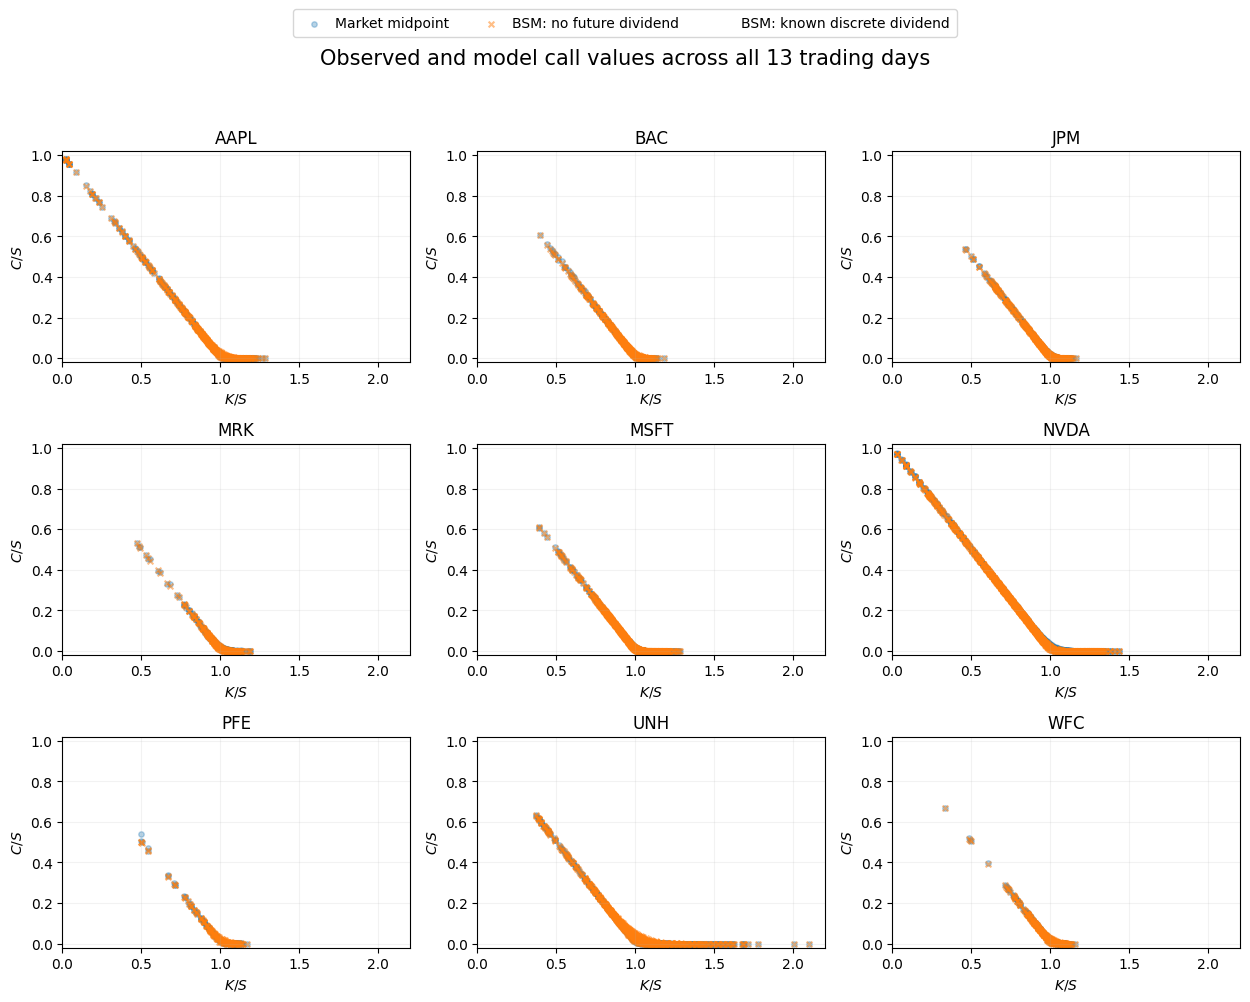

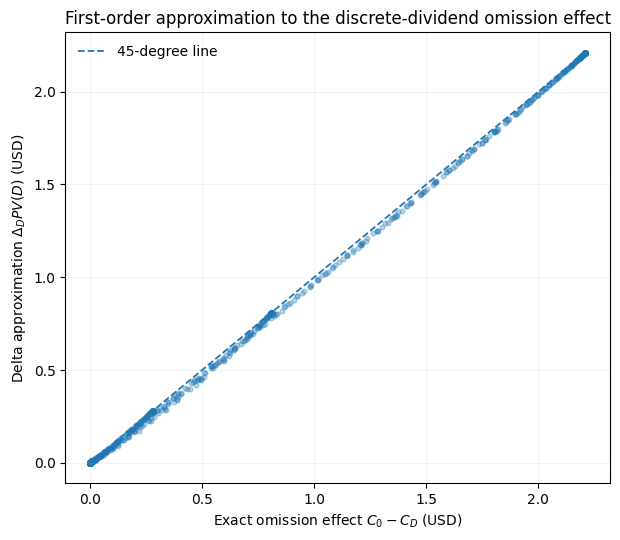

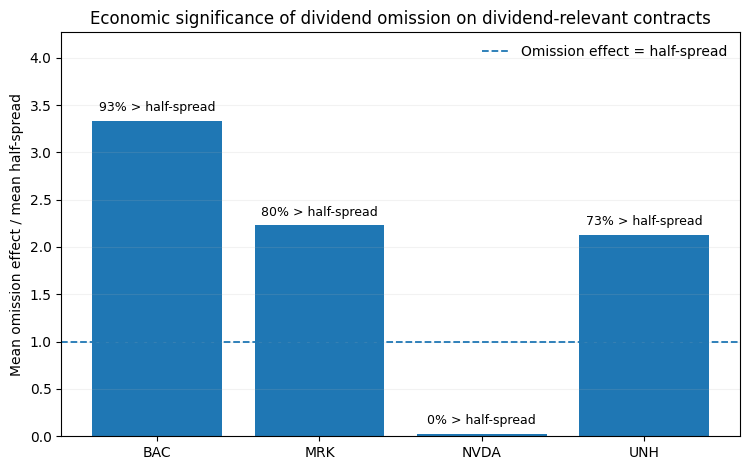

In [12]:
plt.rcParams.update({'font.size':10,'axes.titlesize':12,'axes.labelsize':10,'legend.fontsize':10})
fig,axes=plt.subplots(3,3,figsize=(12.6,10.2))
for ax,sym in zip(axes.ravel(),TICKERS):
    g=prim[prim.symbol==sym]
    ax.scatter(g.K_over_S,g.market_mid/g.S,s=15,alpha=.32,marker='o',label='Market midpoint',rasterized=True)
    ax.scatter(g.K_over_S,g.C0/g.S,s=17,alpha=.50,marker='x',label='BSM: no future dividend',rasterized=True)
    ax.scatter(g.K_over_S,g.CD/g.S,s=22,alpha=.50,marker='^',facecolors='none',label='BSM: known discrete dividend',rasterized=True)
    ax.set_title(sym,pad=6);ax.set_xlabel('$K/S$');ax.set_ylabel('$C/S$');ax.set_xlim(0,2.2);ax.set_ylim(-.02,1.02);ax.grid(alpha=.16)
h,l=axes[0,0].get_legend_handles_labels();fig.legend(h,l,loc='upper center',ncol=3,frameon=True,bbox_to_anchor=(.5,.985),columnspacing=2,handletextpad=.5,borderpad=.5)
fig.suptitle('Observed and model call values across all 13 trading days',y=.94,fontsize=15);fig.tight_layout(rect=(0,0,1,.91))
fig.savefig(FIG/'figure1_normalized_prices_discrete.png',dpi=300,bbox_inches='tight');plt.show()

fig,ax=plt.subplots(figsize=(6.3,5.5));ax.scatter(relevant.omission,relevant.approx,s=12,alpha=.30,rasterized=True);lo=min(relevant.omission.min(),relevant.approx.min());hi=max(relevant.omission.max(),relevant.approx.max());ax.plot([lo,hi],[lo,hi],linestyle='--',linewidth=1.3,label='45-degree line');ax.set_xlabel('Exact omission effect $C_0-C_D$ (USD)');ax.set_ylabel('Delta approximation $\\Delta_D PV(D)$ (USD)');ax.set_title('First-order approximation to the discrete-dividend omission effect');ax.grid(alpha=.16);ax.legend(frameon=False);fig.tight_layout();fig.savefig(FIG/'figure2_discrete_approximation.png',dpi=300,bbox_inches='tight');plt.show()

e=economic[economic['Relevant N']>0].copy();fig,ax=plt.subplots(figsize=(7.6,4.8));bars=ax.bar(e.Ticker,e.Ratio);ax.axhline(1,linestyle='--',linewidth=1.3,label='Omission effect = half-spread');ax.set_ylabel('Mean omission effect / mean half-spread');ax.set_title('Economic significance of dividend omission on dividend-relevant contracts');ax.grid(axis='y',alpha=.16)
for b,share in zip(bars,e['Share > halfspread']): ax.text(b.get_x()+b.get_width()/2,b.get_height()+.07,f'{100*share:.0f}% > half-spread',ha='center',va='bottom',fontsize=9)
ax.legend(frameon=False);ax.set_ylim(0,max(e.Ratio)*1.28);fig.tight_layout();fig.savefig(FIG/'figure3_omission_vs_halfspread.png',dpi=300,bbox_inches='tight');plt.show()


## 10. Robustness checks

The appendix table reported in the manuscript is generated here. It varies the historical-volatility window, the activity screen, and the relative-spread cap while retaining the same discrete-dividend timing logic and no-arbitrage screens. The former continuous-yield specification is also reported separately as an alternative dividend treatment.


In [13]:
# Former continuous-yield specification on the final filtered sample.
prim['q_yahoo']=pd.to_numeric(prim.dividend_yield,errors='coerce')
prim['Cq_cont']=bsm_continuous_q(prim.S,prim.K,prim.T_years,RISK_FREE,prim.sigma_hv20,prim.q_yahoo)
prim['AEq_cont']=(prim.Cq_cont-prim.market_mid).abs()
cont=[]
for sym in TICKERS:
    g=prim[prim.symbol==sym];m0=g.AE0.mean();mq=g.AEq_cont.mean()
    cont.append([sym,len(g),m0,mq,100*(m0-mq)/m0])
continuous_robustness=pd.DataFrame(cont,columns=['Ticker','N','MAE 0','MAE continuous q','MAE change %'])
display(continuous_robustness)
continuous_robustness.to_csv(TAB/'continuous_yield_robustness.csv',index=False)

# Helper for the discrete-dividend robustness variants.
def select_variant(max_sessions=1,spread_cap=None):
    m=stage3 & raw.trade_age_sessions.notna() & (raw.trade_age_sessions>=0) & (raw.trade_age_sessions<=max_sessions)
    if spread_cap is not None:
        m &= raw.relative_spread<=spread_cap
    return raw.loc[m].copy()

def price_variant(d,n=20):
    d=d.copy(); d['sigma']=d.symbol.map(sigmas[n])
    d['p0']=bs_call(d.S,d.K,d.T_years,RISK_FREE,d.sigma)
    d['pd']=bs_call(d.S_adj,d.K,d.T_years,RISK_FREE,d.sigma)
    d['e0']=(d.p0-d.market_mid).abs(); d['ed']=(d.pd-d.market_mid).abs()
    return d

specifications=[
    ('Primary: HV20, activity <=1',20,1,None),
    ('HV10, activity <=1',10,1,None),
    ('HV15, activity <=1',15,1,None),
    ('Same-day activity only',20,0,None),
    ('Activity <=2 sessions',20,2,None),
    ('Spread <=25%',20,1,0.25),
    ('Spread <=50%',20,1,0.50),
    ('Spread <=100%',20,1,1.00),
]
rob_rows=[]
for name,n,sessions,cap in specifications:
    d=price_variant(select_variant(sessions,cap),n)
    row={'Specification':name,'N':len(d)}
    for sym in ['BAC','MRK','NVDA','UNH']:
        g=d[d.symbol==sym]; m0=g.e0.mean(); md=g.ed.mean()
        row[sym]=100*(m0-md)/m0
    rob_rows.append(row)
robustness_summary=pd.DataFrame(rob_rows)
display(robustness_summary)
robustness_summary.to_csv(TAB/'robustness_summary.csv',index=False)


,Ticker,N,MAE 0,MAE continuous q,MAE change %
0,AAPL,482,0.253078,0.260468,-2.919906
1,BAC,361,0.076756,0.074283,3.222434
2,JPM,398,0.479806,0.575949,-20.037862
3,MRK,262,0.174183,0.197701,-13.501914
4,MSFT,681,0.443037,0.485900,-9.674826
5,NVDA,1002,0.351955,0.352559,-0.171426
6,PFE,160,0.055017,0.059019,-7.274708
7,UNH,662,1.280333,1.222735,4.498697
8,WFC,299,0.109243,0.128963,-18.051864


,Specification,N,BAC,MRK,NVDA,UNH
0,"Primary: HV20, activity <=1",4307,-30.318490,-137.237723,-1.006086,-2.182417
1,"HV10, activity <=1",4307,-69.615464,-149.033230,-1.001919,5.114217
2,"HV15, activity <=1",4307,-65.307128,-146.436872,-0.904047,-3.266252
3,Same-day activity only,3831,-30.553086,-127.667056,-0.973374,1.212300
4,Activity <=2 sessions,4532,-26.825867,-148.835293,-1.029839,-4.727649
5,Spread <=25%,3661,-30.978372,-147.705562,-1.014825,-2.589718
6,Spread <=50%,3919,-30.459821,-144.631909,-1.009377,-2.286184
7,Spread <=100%,4204,-30.318490,-141.589935,-1.006086,-2.206166


## 11. Auxiliary American-style and quote diagnostics

The manuscript's primary comparison is deliberately a **European benchmark** so that the dividend omission effect is controlled within a common pricing framework. The observed U.S. single-stock options are American-style, however, so the replication notebook provides two auxiliary diagnostics without changing the primary sample or the reported main results.

1. **Intrinsic-value diagnostic.** For each retained call, compare the quoted midpoint with the American-call intrinsic value \(\max(S-K,0)\). Any midpoint below intrinsic value is recorded as a quote/timing diagnostic; these observations are **not** removed post hoc from the locked primary specification.
2. **Escrowed-dividend 100-step CRR diagnostic.** For dividend-relevant contracts, subtract the present value of the known future cash dividend from spot to form an escrowed stock component. That component follows a recombining CRR tree. Before the ex-date, the remaining present value of the cash dividend is added back when evaluating the American early-exercise payoff. This is an auxiliary approximation, not a replacement for the paper's primary closed-form European benchmark.


In [14]:
# Intrinsic-value diagnostic for the locked primary sample.
prim['intrinsic_value'] = np.maximum(prim.S - prim.K, 0.0)
prim['mid_minus_intrinsic'] = prim.market_mid - prim.intrinsic_value
prim['mid_below_intrinsic'] = prim.market_mid + 1e-12 < prim.intrinsic_value

intrinsic_diag = (prim.groupby('symbol')
                  .agg(N=('symbol','size'),
                       below_intrinsic=('mid_below_intrinsic','sum'),
                       min_mid_minus_intrinsic=('mid_minus_intrinsic','min'))
                  .reset_index())
intrinsic_diag['share_below_intrinsic'] = intrinsic_diag['below_intrinsic'] / intrinsic_diag['N']
display(intrinsic_diag)
intrinsic_diag.to_csv(TAB/'intrinsic_value_diagnostic.csv', index=False)

# 100-step escrowed-dividend CRR approximation.
def escrowed_crr_call(S, K, T, r, sigma, D=0.0, tau=np.nan, steps=100, american=True):
    S=float(S); K=float(K); T=float(T); sigma=float(sigma)
    if not (S > 0 and K > 0 and T > 0 and sigma > 0):
        return np.nan

    if np.isfinite(tau) and D > 0 and 0 < tau < T:
        D=float(D); tau=float(tau)
        pv0 = D*np.exp(-r*tau)
    else:
        D=0.0; tau=np.nan; pv0=0.0

    X0 = S - pv0
    if X0 <= 0:
        return np.nan

    dt = T/steps
    u = np.exp(sigma*np.sqrt(dt))
    d = 1.0/u
    disc = np.exp(-r*dt)
    p = (np.exp(r*dt)-d)/(u-d)
    if not (0 <= p <= 1):
        return np.nan

    k = np.arange(steps+1)
    X = X0*(u**k)*(d**(steps-k))
    V = np.maximum(X-K, 0.0)  # dividend is before expiry for the relevant contracts

    for j in range(steps-1, -1, -1):
        V = disc*(p*V[1:] + (1-p)*V[:-1])
        if american:
            kk = np.arange(j+1)
            Xj = X0*(u**kk)*(d**(j-kk))
            tj = j*dt
            remaining_div_pv = D*np.exp(-r*(tau-tj)) if (D > 0 and tj < tau) else 0.0
            Sj = Xj + remaining_div_pv
            V = np.maximum(V, Sj-K)
    return float(V[0])

crr = prim[prim.PV_div > 0].copy()
crr['CRR_european_escrowed'] = [
    escrowed_crr_call(r.S, r.K, r.T_years, RISK_FREE, r.sigma_hv20,
                      r.dividend_amount, r.tau_div, steps=100, american=False)
    for r in crr.itertuples()
]
crr['CRR_american_escrowed'] = [
    escrowed_crr_call(r.S, r.K, r.T_years, RISK_FREE, r.sigma_hv20,
                      r.dividend_amount, r.tau_div, steps=100, american=True)
    for r in crr.itertuples()
]
crr['CRR_early_exercise_premium'] = crr.CRR_american_escrowed - crr.CRR_european_escrowed
crr['CRR_AE_american'] = (crr.CRR_american_escrowed - crr.market_mid).abs()
crr['CRR_AE_european'] = (crr.CRR_european_escrowed - crr.market_mid).abs()

crr_summary = (crr.groupby('symbol')
               .agg(N=('symbol','size'),
                    mean_early_exercise_premium=('CRR_early_exercise_premium','mean'),
                    p95_early_exercise_premium=('CRR_early_exercise_premium', lambda x: x.quantile(.95)),
                    max_early_exercise_premium=('CRR_early_exercise_premium','max'),
                    american_MAE=('CRR_AE_american','mean'),
                    european_tree_MAE=('CRR_AE_european','mean'))
               .reset_index())
display(crr_summary)
crr.to_csv(TAB/'escrowed_crr_diagnostic.csv', index=False)
crr_summary.to_csv(TAB/'escrowed_crr_summary.csv', index=False)

print('Intrinsic diagnostic — total midpoint-below-intrinsic observations:', int(prim.mid_below_intrinsic.sum()))
print('CRR diagnostic — dividend-relevant contracts:', len(crr))


,symbol,N,below_intrinsic,min_mid_minus_intrinsic,share_below_intrinsic
0,AAPL,482,0,0.015000,0.000000
1,BAC,361,12,-0.044999,0.033241
2,JPM,398,0,0.015000,0.000000
3,MRK,262,23,-0.609998,0.087786
4,MSFT,681,0,0.015000,0.000000
5,NVDA,1002,0,0.009995,0.000000
6,PFE,160,0,0.005000,0.000000
7,UNH,662,43,-1.099988,0.064955
8,WFC,299,0,0.015000,0.000000


,symbol,N,mean_early_exercise_premium,p95_early_exercise_premium,max_early_exercise_premium,american_MAE,european_tree_MAE
0,BAC,134,0.122338,0.231174,0.245927,0.050440,0.162672
1,MRK,188,0.343956,0.777218,0.790097,0.218543,0.490405
2,NVDA,567,0.000027,0.000000,0.005149,0.401256,0.401284
3,UNH,451,0.894241,2.110151,2.145468,1.378155,1.715732


Intrinsic diagnostic — total midpoint-below-intrinsic observations: 78
CRR diagnostic — dividend-relevant contracts: 1340


## 12. Reproducibility checks and export


In [15]:
# Core sample checks from the locked final manuscript.
assert len(raw) == 9959, len(raw)
assert int(stage1.sum()) == 7938, stage1.sum()
assert int(stage2.sum()) == 7163, stage2.sum()
assert int(stage3.sum()) == 5642, stage3.sum()
assert int(stage4.sum()) == 4307, stage4.sum()
assert len(prim) == 4307, len(prim)
assert len(relevant) == 1340, len(relevant)

# NVIDIA stale-record audit reported in the manuscript.
nv = raw[raw.symbol=='NVDA']
nvf = prim[prim.symbol=='NVDA']
assert len(nv) == 3037
assert int((nv.K > 200).sum()) == 1599
assert int(((nv.K > 200) & (nv.last_trade_date < pd.Timestamp('2024-06-10'))).sum()) == 1092
assert len(nvf) == 1002
assert int((nvf.last_trade_date < pd.Timestamp('2024-06-10')).sum()) == 0
assert abs(nvf.K.max() - 250.0) < 1e-12
assert abs(nvf.K_over_S.max() - 1.435) < 0.001

# Mechanical-effect and economic-significance checks.
assert abs(np.corrcoef(relevant.omission,relevant.approx)[0,1] - 0.9999076860507335) < 1e-10
assert abs(relevant.approx_err.mean() - 0.00608) < 5e-5
assert abs(prim.omission.mean() - 0.155) < 5e-4
assert abs(prim.half_spread.mean() - 0.374) < 5e-4
assert abs(relevant.omission.mean() - 0.499) < 5e-4
assert abs(relevant.half_spread.mean() - 0.339) < 5e-4

expected_econ = {
    'BAC': (134, 0.209, 0.063, 3.33, 0.933),
    'MRK': (188, 0.422, 0.189, 2.23, 0.798),
    'NVDA':(567, 0.006, 0.262, 0.02, 0.000),
    'UNH': (451, 1.237, 0.581, 2.13, 0.732),
}
for sym,(n,om,hs,ratio,share) in expected_econ.items():
    row=economic.loc[economic.Ticker==sym].iloc[0]
    assert int(row['Relevant N']) == n
    assert abs(row['Mean omission']-om) < 0.001
    assert abs(row['Mean halfspread']-hs) < 0.001
    assert abs(row['Ratio']-ratio) < 0.02
    assert abs(row['Share > halfspread']-share) < 0.005

# Moneyness table checks.
assert int(moneyness_summary['N'].sum()) == 4307
expected_moneyness_n = {'Deep ITM':968,'ITM':1131,'ATM':1156,'OTM':799,'Deep OTM':253}
for b,n in expected_moneyness_n.items():
    assert int(moneyness_summary.loc[moneyness_summary.Moneyness==b,'N'].iloc[0]) == n

# Robustness table checks.
assert int(robustness_summary.loc[robustness_summary.Specification.str.startswith('Primary'),'N'].iloc[0]) == 4307

# Auxiliary diagnostics are intentionally not primary filters/results.
assert len(crr) == 1340
assert int(prim.mid_below_intrinsic.sum()) >= 0

print('All final-draft reproducibility checks passed.')

# Save the declared dividend schedule used by the analysis.
cols=[c for c in ['symbol','ex_date','dividend_amount','source_url','note'] if c in dividends.columns]
dividends[cols].to_csv(TAB/'dividend_schedule_used.csv',index=False)

# Small manifest for users checking the generated outputs.
manifest = pd.DataFrame({
    'item': ['raw_rows','valid_quotes','upper_bound','lower_bound','primary_rows','dividend_relevant_rows'],
    'value': [len(raw),int(stage1.sum()),int(stage2.sum()),int(stage3.sum()),len(prim),len(relevant)]
})
manifest.to_csv(TAB/'final_draft_manifest.csv',index=False)
display(manifest)

if IN_COLAB:
    archive=shutil.make_archive('/content/BSM_final_draft_results','zip',ROOT/'revised_outputs_final_draft')
    from google.colab import files
    files.download(archive)


All final-draft reproducibility checks passed.


,item,value
0,raw_rows,9959
1,valid_quotes,7938
2,upper_bound,7163
3,lower_bound,5642
4,primary_rows,4307
5,dividend_relevant_rows,1340


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>